# Iris Flower Classification using Machine Learning

- Developed by: Sarfraz Ali Katpar
- Course: Data Science
- Instructor: Dr Muhammad Ismail
- Semster: BSCS-V

Importing Libraries/Frameworks

In [69]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Loading the Iris Datset

In [70]:

# Load the Iris dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_names'] = df['species'].map(lambda x: iris.target_names[x])

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Exploratory Data Analysis

In [71]:
# Perform EDA: shape, dtypes, null value check, descriptive statistics

print("DataFrame Shape:", df.shape)
print("\nDataFrame Info:")
df.info()

DataFrame Shape: (150, 6)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_names      150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [72]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_names        0
dtype: int64


In [73]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


Data Visualisation

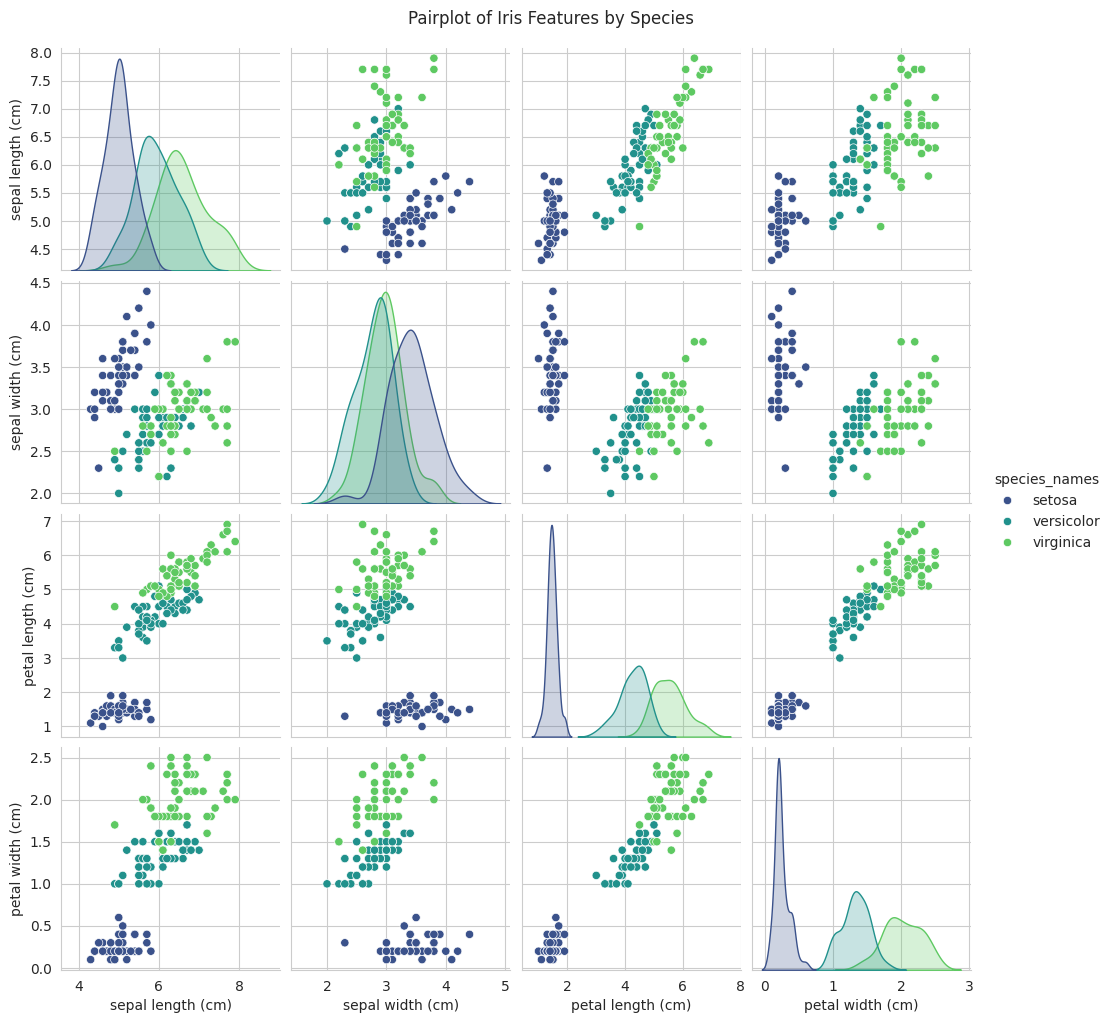

In [74]:
sns.set_style("whitegrid")
# Create a pairplot to visualize feature distributions by species
sns.pairplot(df, hue='species_names', vars=iris.feature_names, palette='viridis')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02) # Add a title above the plots
plt.show()

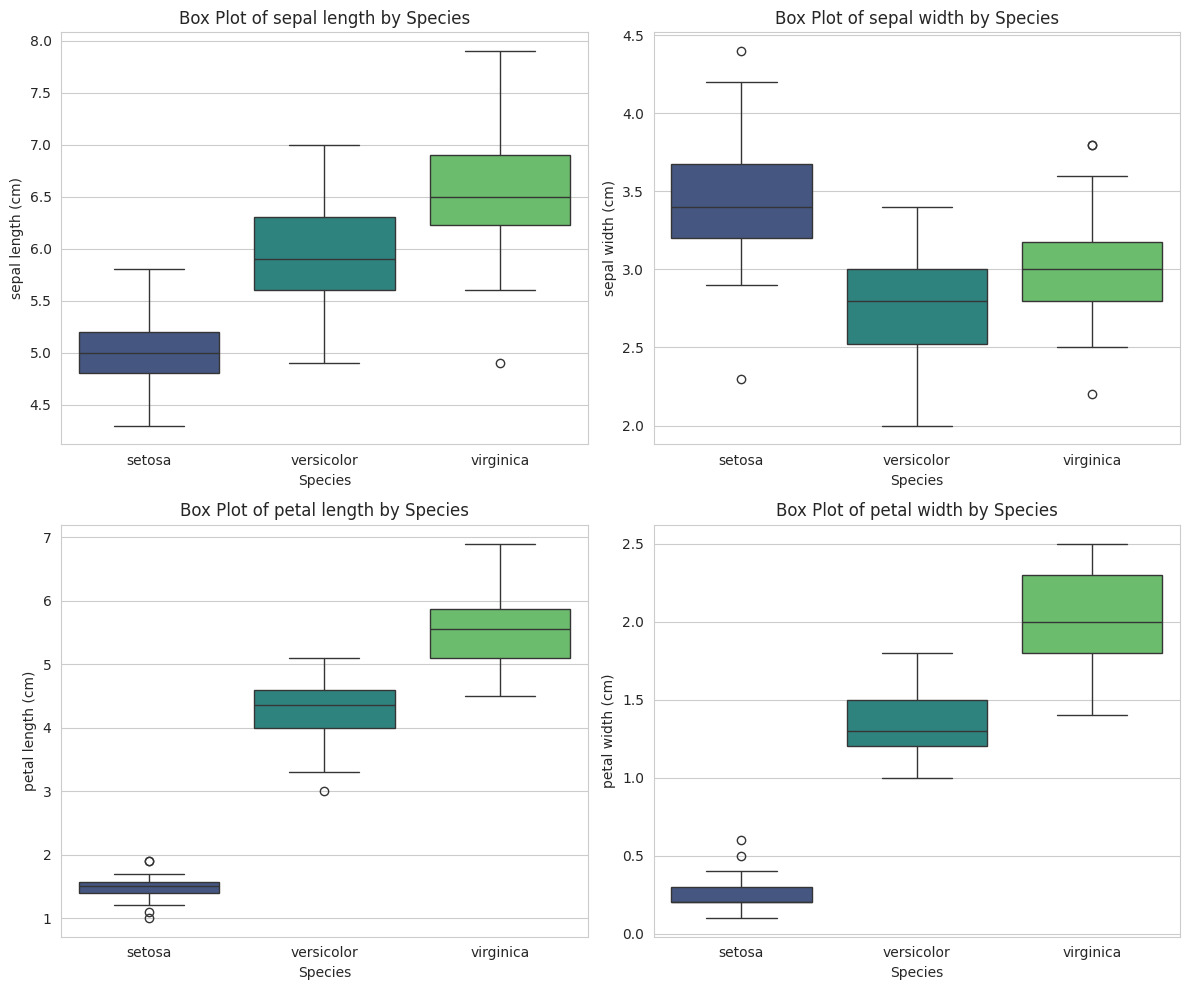

In [75]:
# Create box plots for each feature
plt.figure(figsize=(12, 10))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1) # 2x2 grid for 4 features
    sns.boxplot(x='species_names', y=feature, data=df, hue='species_names', palette='viridis', legend=False)
    plt.title(f'Box Plot of {feature.replace(" (cm)", "")} by Species')
    plt.xlabel('Species')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

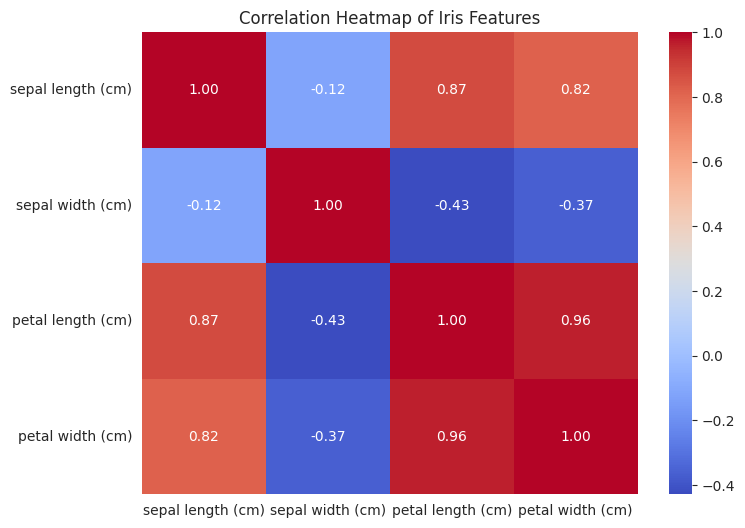

In [76]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Iris Features')
plt.show()

## Feature Selection Discussion

Based on the visualizations:

*   **Petal Length (cm) and Petal Width (cm):** These two features show the clearest separation among the three iris species. Setosa is distinctly separated from Versicolor and Virginica, and there's a relatively good separation between Versicolor and Virginica as well, particularly with petal length.
*   **Sepal Length (cm):** While there's some overlap, sepal length also shows a degree of separation. Setosa generally has shorter sepal lengths, while Virginica has longer ones.
*   **Sepal Width (cm):** This feature appears to be the least discriminative. There's significant overlap across all three species, making it difficult to differentiate them based solely on sepal width.

**Conclusion:** Petal length and petal width are the most discriminative features. We will use all features for training our models.

Splitting the Data

In [77]:
# Define features (X) and target (y)
X = df[iris.feature_names]
y = df['species']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [78]:
print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in training data:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test data:")
print(y_test.value_counts(normalize=True))


Class distribution in original data:
species
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

Class distribution in training data:
species
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64

Class distribution in test data:
species
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


## Train and Evaluate Classification Models
- Logistic Regression
- K-Nearest Neighbors

In [79]:
# Initialize models
logistic_model = LogisticRegression(random_state=42, max_iter=200)
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point

models = {
    'Logistic Regression': logistic_model,
    'K-Nearest Neighbors': knn_model
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # Train the model
    model.fit(X_train, y_train)




--- Training Logistic Regression ---

--- Training K-Nearest Neighbors ---


Predictions

In [80]:
# Make predictions
y_pred = model.predict(X_test)

Model Evaluation

In [81]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)

results[name] = {
          'accuracy': accuracy,
          'confusion_matrix': conf_matrix,
          'classification_report': class_report
      }

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 1.0000
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Best Model for Iris Classification

In [82]:
# Identify and declare the best-performing model (based on accuracy for simplicity)
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print(f"\n--- Best Performing Model ---")
print(f"The best model is {best_model_name} with an accuracy of {best_accuracy:.4f}")


--- Best Performing Model ---
The best model is K-Nearest Neighbors with an accuracy of 1.0000


## Confusion Matrix Plot for the Best Model (K-Nearest Neighbors)

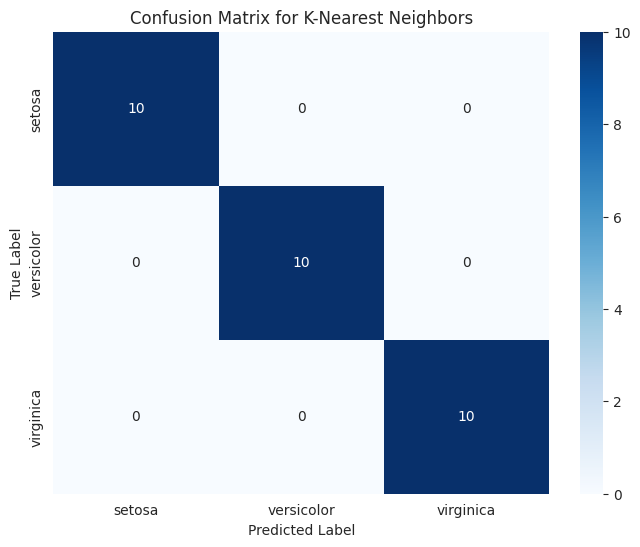

In [83]:
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_conf_matrix = results[best_model_name]['confusion_matrix']

plt.figure(figsize=(8, 6))
sns.heatmap(best_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()

## Analyzing Overfitting: KNN Accuracy vs. Number of Neighbors

A perfect 100% accuracy, especially on a small test set, can sometimes indicate overfitting. To investigate this for our K-Nearest Neighbors model, we'll plot the training and test accuracy as we vary the `n_neighbors` hyperparameter. This will help us visualize if the model is becoming too complex (leading to overfitting on the training data) or too simple (leading to underfitting).

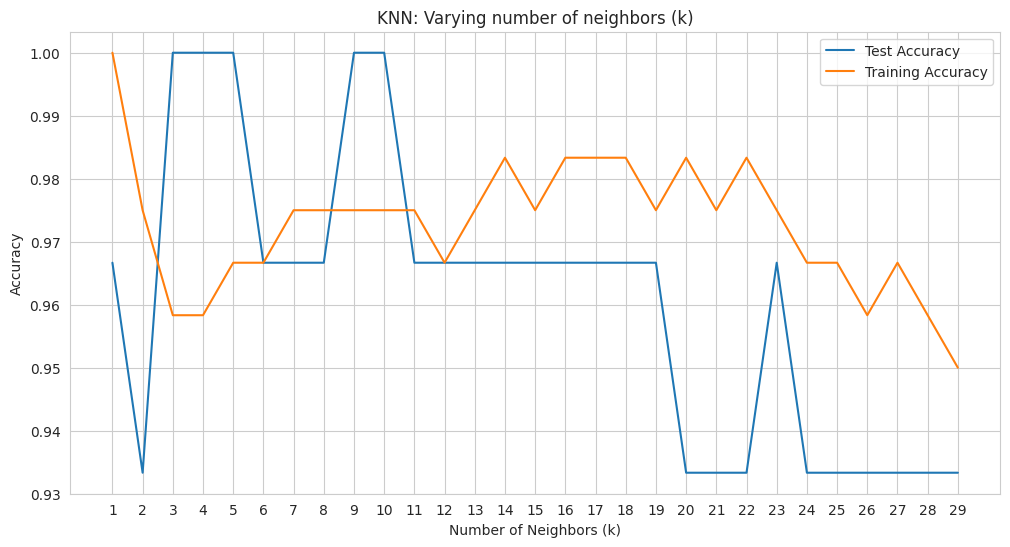

In [84]:
# Define a range of n_neighbors values to test
neighbors = np.arange(1, 30) # Test k from 1 to 29

train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Loop over k values
for i, k in enumerate(neighbors):
    # Setup a KNN Classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model
    knn.fit(X_train, y_train)

    # Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train, y_train)

    # Compute accuracy on the test set
    test_accuracy[i] = knn.score(X_test, y_test)

# Plotting the accuracies
plt.figure(figsize=(12, 6))
plt.title('KNN: Varying number of neighbors (k)')
plt.plot(neighbors, test_accuracy, label='Test Accuracy')
plt.plot(neighbors, train_accuracy, label='Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(neighbors)
plt.grid(True)
plt.show()

### Interpretation:

*   **High Training Accuracy, Low Test Accuracy:** If the training accuracy is significantly higher than the test accuracy, especially for small `k` values, it suggests overfitting. The model has learned the training data too well, including its noise, and struggles to generalize to unseen data.
*   **Low Training Accuracy, Low Test Accuracy:** If both accuracies are low, it might indicate underfitting. The model is too simple to capture the underlying patterns in the data.
*   **Converging Accuracies:** Ideally, we look for a `k` value where both training and test accuracies are high and relatively close to each other, indicating a good balance between bias and variance.

Given the small size of the Iris dataset (150 samples) and an even smaller test set (30 samples), a perfect 100% accuracy on the test set is not uncommon, especially if the decision boundaries are very clear. The plot will help us understand if this is stable across different `k` values or if it's an anomaly at `k=5`.